### Import Libraries

In [18]:
from pathlib import Path
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import hog
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from torchvision.datasets import GTSRB


### Load GTSRB

In [19]:
DATA_DIR = Path("../data")

train_dataset = GTSRB(
    root=DATA_DIR,
    split="train",
    download=False
)

test_dataset = GTSRB(
    root=DATA_DIR,
    split="test",
    download=False
)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
num_classes = len(set(sample[1] for sample in train_dataset._samples))
print(f"Num classes: {num_classes}")

Train size: 26640
Test size: 12630
Num classes: 43


### Get 1 traffic sign image

In [20]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Class label:", label)

Image type: <class 'PIL.Image.Image'>
Image size: (29, 30)
Class label: 0


### Show 1 traffic sign image

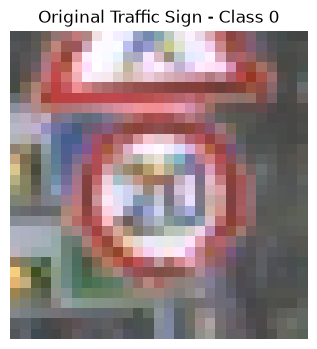

In [21]:
image_np = np.array(image)

plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.title(f"Original Traffic Sign - Class {label}")
plt.axis("off")
plt.show()

### Compute HOG features

In [22]:
image = image.resize((32, 32))
gray = np.array(image.convert("L"))
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    transform_sqrt=True,
    visualize=True,
)

print(f"Feature vector length: {features.shape[0]}")

Feature vector length: 1764


### Visualize HOG components

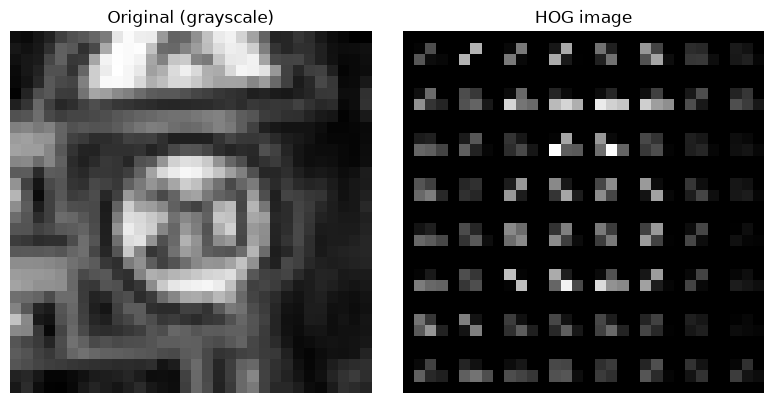

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")
axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG image")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Extract HOG Features for the Full GTSRB Dataset

Extract HOG features for **all** training (26,640) and testing (12,630) images.
Extraction runs in parallel with `joblib` (one process per CPU core).

**Note:** If multiprocessing misbehaves on your machine, set `n_jobs=1`.

In [24]:
def hog_features(pil_image, size=(32, 32), orientations=9,
                 pixels_per_cell=(4, 4), cells_per_block=(2, 2),
                 transform_sqrt=True):
    """Compute HOG features for one PIL image (RGB -> grayscale -> resized)."""
    gray = np.array(pil_image.resize(size).convert("L"))
    return hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        transform_sqrt=transform_sqrt,
    )


def raw_pixel_features(pil_image, size=(32, 32)):
    """Flattened grayscale pixels (baseline feature set, no HOG)."""
    gray = np.array(pil_image.resize(size).convert("L"), dtype=np.float32)
    return gray.reshape(-1)


def extract_features_for_path(path, params):
    """Dispatch to raw pixels or HOG according to the parameter dict."""
    image = Image.open(path).convert("RGB")
    if params.get("raw"):
        return raw_pixel_features(image, size=params.get("size", (32, 32)))
    return hog_features(image, **params)


def extract_dataset(dataset, params, n_jobs=-1):
    """Extract features for every image of a torchvision GTSRB dataset."""
    paths = [sample[0] for sample in dataset._samples]
    labels = np.array([sample[1] for sample in dataset._samples])
    features = Parallel(n_jobs=n_jobs)(
        delayed(extract_features_for_path)(p, params) for p in paths
    )
    return np.array(features, dtype=np.float32), labels


DEFAULT_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    transform_sqrt=True,
)

FEATURE_DIR = Path("../features")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
EXP_DIR = FEATURE_DIR / "hog_experiments"
EXP_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()
X_train, y_train = extract_dataset(train_dataset, DEFAULT_PARAMS)
print(f"Training set : {X_train.shape} extracted in {time.time() - t0:.1f}s")

t0 = time.time()
X_test, y_test = extract_dataset(test_dataset, DEFAULT_PARAMS)
print(f"Testing set  : {X_test.shape} extracted in {time.time() - t0:.1f}s")

Training set : (26640, 1764) extracted in 8.4s
Testing set  : (12630, 1764) extracted in 8.3s


### Save Features

Saved to `../features/` so the classifier members (Task 2) can reuse them.

In [25]:
np.savez_compressed(FEATURE_DIR / "gtsrb_hog_features_train.npz",
                    X=X_train, y=y_train)
np.savez_compressed(FEATURE_DIR / "gtsrb_hog_features_test.npz",
                    X=X_test, y=y_test)

# Also cache under the experiment name so Section 5 can reuse it
np.savez_compressed(EXP_DIR / "hog_o9_c4_b2_sqrt_train.npz", X=X_train)
np.savez_compressed(EXP_DIR / "hog_o9_c4_b2_sqrt_test.npz", X=X_test)

print(f"Saved to {FEATURE_DIR.resolve()}")

Saved to C:\Users\khory\Desktop\traffic-sign-recognition\features


## 4. Verify on the GTSRB Test Set

Train a fixed classifier (linear SVM) on the extracted HOG features and
verify the recognition rate on the **GTSRB test set** (12,630 images).

In [26]:
final_clf = LinearSVC(random_state=42, max_iter=3000)
final_clf.fit(X_train, y_train)

test_accuracy = final_clf.score(X_test, y_test)
print(f"GTSRB test-set recognition rate: {test_accuracy * 100:.2f}% "
      f"({int(test_accuracy * len(y_test))}/{len(y_test)})")

GTSRB test-set recognition rate: 89.14% (11259/12630)


## 5. Recognition Rate for Different Sets of Features

The classifier is kept **fixed** (linear SVM, same hyper-parameters) while the
feature set is varied, so any difference in recognition rate is due to the
features alone.

| Feature set | Description |
|---|---|
| `raw_pixels_gray` | Flattened 32×32 grayscale pixels (baseline, no HOG) |
| `hog_o9_c4_b2_sqrt` | HOG: 9 orientations, cell 4×4, block 2×2, sqrt transform |
| `hog_o12_c4_b2_sqrt` | More orientation bins (12) |
| `hog_o9_c8_b2_sqrt` | Coarser cells (8×8) |
| `hog_o9_c4_b1_sqrt` | No block normalisation (block 1×1) |
| `hog_o9_c4_b2_nosqrt` | Without the sqrt transform |
| `hog_o9_c4_b2_s64` | Higher resolution input (64×64) |

Extracted features are cached under `../features/hog_experiments/` so
re-running this cell is instant.

In [ ]:
CONFIGS = {
    "raw_pixels_gray":     dict(raw=True, size=(32, 32)),
    "hog_o9_c4_b2_sqrt":   dict(orientations=9,  pixels_per_cell=(4, 4), cells_per_block=(2, 2), transform_sqrt=True),
    "hog_o12_c4_b2_sqrt":  dict(orientations=12, pixels_per_cell=(4, 4), cells_per_block=(2, 2), transform_sqrt=True),
    "hog_o9_c8_b2_sqrt":   dict(orientations=9,  pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True),
    "hog_o9_c4_b1_sqrt":   dict(orientations=9,  pixels_per_cell=(4, 4), cells_per_block=(1, 1), transform_sqrt=True),
    "hog_o9_c4_b2_nosqrt": dict(orientations=9,  pixels_per_cell=(4, 4), cells_per_block=(2, 2), transform_sqrt=False),
    "hog_o9_c4_b2_s64":    dict(orientations=9,  pixels_per_cell=(4, 4), cells_per_block=(2, 2), transform_sqrt=True, size=(64, 64)),
}

train_paths = [sample[0] for sample in train_dataset._samples]
test_paths = [sample[0] for sample in test_dataset._samples]
y_train_full = np.array([sample[1] for sample in train_dataset._samples])
y_test_full = np.array([sample[1] for sample in test_dataset._samples])

results = []
for name, params in CONFIGS.items():
    train_cache = EXP_DIR / f"{name}_train.npz"
    test_cache = EXP_DIR / f"{name}_test.npz"

    if train_cache.exists() and test_cache.exists():
        X_tr = np.load(train_cache)["X"]
        X_te = np.load(test_cache)["X"]
        print(f"[{name}] loaded cached features", flush=True)
    else:
        t0 = time.time()
        X_tr = np.array(Parallel(n_jobs=-1)(
            delayed(extract_features_for_path)(p, params) for p in train_paths
        ), dtype=np.float32)
        X_te = np.array(Parallel(n_jobs=-1)(
            delayed(extract_features_for_path)(p, params) for p in test_paths
        ), dtype=np.float32)
        np.savez_compressed(train_cache, X=X_tr)
        np.savez_compressed(test_cache, X=X_te)
        print(f"[{name}] extracted in {time.time() - t0:.1f}s", flush=True)

    if params.get("raw"):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

    t0 = time.time()
    clf = LinearSVC(random_state=42, max_iter=3000)
    clf.fit(X_tr, y_train_full)
    accuracy = clf.score(X_te, y_test_full)

    results.append({
        "Feature set": name,
        "Feature dimensions": X_tr.shape[1],
        "Test accuracy (%)": round(accuracy * 100, 2),
        "Train time (s)": round(time.time() - t0, 1),
    })
    print(f"[{name}] dims={X_tr.shape[1]}  test accuracy={accuracy * 100:.2f}%",
          flush=True)

results_df = (pd.DataFrame(results)
              .sort_values("Test accuracy (%)", ascending=False)
              .reset_index(drop=True))

[raw_pixels_gray] extracted in 25.2s


### Results Table

In [ ]:
results_df

In [ ]:
results_df.to_csv(FEATURE_DIR / "hog_feature_sets_recognition_rates.csv", index=False)
print(f"Saved to {FEATURE_DIR / 'hog_feature_sets_recognition_rates.csv'}")

### Results Chart

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
order = results_df["Feature set"][::-1]
values = results_df["Test accuracy (%)"][::-1]

ax.barh(order, values, color="#4C72B0")
ax.set_xlabel("Test accuracy (%)")
ax.set_title("Recognition rate per feature set (GTSRB test set)")
ax.set_xlim(0, 100)
for i, v in enumerate(values):
    ax.text(v + 0.5, i, f"{v:.2f}%", va="center")
plt.tight_layout()
plt.show()

## 6. Verify on the 84 Inputs/ Images (Segmented)

The segmentation pipeline is the one from `proposal/Shape Detection.ipynb`:

1. Load the image (`cv2.imread`).
2. Colour segmentation according to the folder the image lives in:
   `segment_blue()` / `segment_red()` / `segment_yellow()` (defined in
   `proposal/Color Segmentation.ipynb`).
3. `find_best_contour()` selects the sign contour by the geometric score
   `area × circularity × solidity`.
4. Crop the bounding rectangle of the contour, keep only the masked sign
   pixels, resize to 32×32 and extract HOG features.
5. Classify with the linear SVM trained on GTSRB.

**Ground truth:** the sign class is encoded in each filename as the number
before the first underscore (e.g. `020_0002_j.png` → sign 20). The table
below compares the predicted GTSRB class against this label.

In [ ]:
# Run the colour segmentation module from the proposal (defines
# segment_red / segment_blue / segment_yellow)
color_segmentation_nb = str(
    (Path("..") / "proposal" / "Color Segmentation.ipynb").resolve()
)
%run $color_segmentation_nb

In [ ]:
def find_best_contour(mask):
    """Select the most sign-like contour (same scoring as Shape Detection.ipynb,
    without the per-contour print spam)."""
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    best_contour = None
    best_score = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 1000:
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        hull_area = cv2.contourArea(cv2.convexHull(cnt))
        if hull_area == 0:
            continue
        solidity = area / hull_area
        circularity = 4 * np.pi * area / (perimeter * perimeter)
        score = area * circularity * solidity
        if score > best_score:
            best_score = score
            best_contour = cnt
    return best_contour


# Optional: if your team maps the Inputs filename IDs to GTSRB classes,
# fill this dict, e.g. {52: 5} if Inputs sign 52 is GTSRB class 5.
LABEL_MAPPING = {}


def actual_label(image_path):
    file_id = int(image_path.name.split("_")[0])
    return LABEL_MAPPING.get(file_id, file_id)

In [ ]:
INPUT_DIR = Path("../data/Inputs")

image_paths = sorted(
    p for p in INPUT_DIR.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
)
print(f"Inputs images found: {len(image_paths)}")

# Use the classifier trained on the default HOG configuration in Section 4;
# retrain it here if this cell is run on its own
if "final_clf" not in globals():
    X_tr = np.load(EXP_DIR / "hog_o9_c4_b2_sqrt_train.npz")["X"]
    y_tr = np.load(FEATURE_DIR / "gtsrb_hog_features_train.npz")["y"]
    final_clf = LinearSVC(random_state=42, max_iter=3000).fit(X_tr, y_tr)

rows = []
for image_path in image_paths:
    folder = image_path.parent.name
    actual = actual_label(image_path)
    img = cv2.imread(str(image_path))

    if img is None:
        rows.append({"image": image_path.name, "folder": folder,
                     "actual": actual, "predicted": None, "correct": False,
                     "note": "read failed"})
        continue

    if folder == "Blue Signs":
        mask = segment_blue(img)
    elif folder == "Red signs":
        mask = segment_red(img)
    elif folder == "Yellow Signs":
        mask = segment_yellow(img)
    else:
        mask = None

    contour = find_best_contour(mask) if mask is not None else None
    if contour is None:
        rows.append({"image": image_path.name, "folder": folder,
                     "actual": actual, "predicted": None, "correct": False,
                     "note": "no sign detected"})
        continue

    x, y, w, h = cv2.boundingRect(contour)
    crop = img[y:y + h, x:x + w].copy()
    crop_mask = mask[y:y + h, x:x + w]
    crop[crop_mask == 0] = 0
    crop_rgb = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    features = hog_features(crop_rgb, **DEFAULT_PARAMS)
    predicted = int(final_clf.predict(features.reshape(1, -1))[0])

    rows.append({"image": image_path.name, "folder": folder,
                 "actual": actual, "predicted": predicted,
                 "correct": predicted == actual, "note": ""})

inputs_df = pd.DataFrame(rows)

### Recognition Rate on the Inputs/ Images

In [ ]:
total = len(inputs_df)
correct_count = int(inputs_df["correct"].sum())
print(f"Overall recognition rate: {correct_count / total * 100:.2f}% "
      f"({correct_count}/{total})")

per_folder = (inputs_df
              .groupby("folder")
              .agg(images=("image", "count"),
                   correct=("correct", "sum"))
              .assign(rate_pct=lambda d: (d["correct"] / d["images"] * 100).round(2))
              .reset_index())
per_folder

### Per-Image Results Table

In [ ]:
inputs_df

In [ ]:
inputs_df.to_csv(FEATURE_DIR / "assignment1_hog_recognition_results.csv",
                 index=False)
print(f"Saved to {FEATURE_DIR / 'assignment1_hog_recognition_results.csv'}")

### Sample Segmentations

In [ ]:
samples = inputs_df.head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, samples.itertuples()):
    image_path = INPUT_DIR / row.folder / row.image
    img = cv2.imread(str(image_path))
    folder = row.folder
    if folder == "Blue Signs":
        mask = segment_blue(img)
    elif folder == "Red signs":
        mask = segment_red(img)
    else:
        mask = segment_yellow(img)
    contour = find_best_contour(mask)

    result = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    if contour is not None:
        cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
    ax.imshow(result)
    ax.set_title(f"{row.image}\nactual={row.actual}  predicted={row.predicted}",
                 fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()